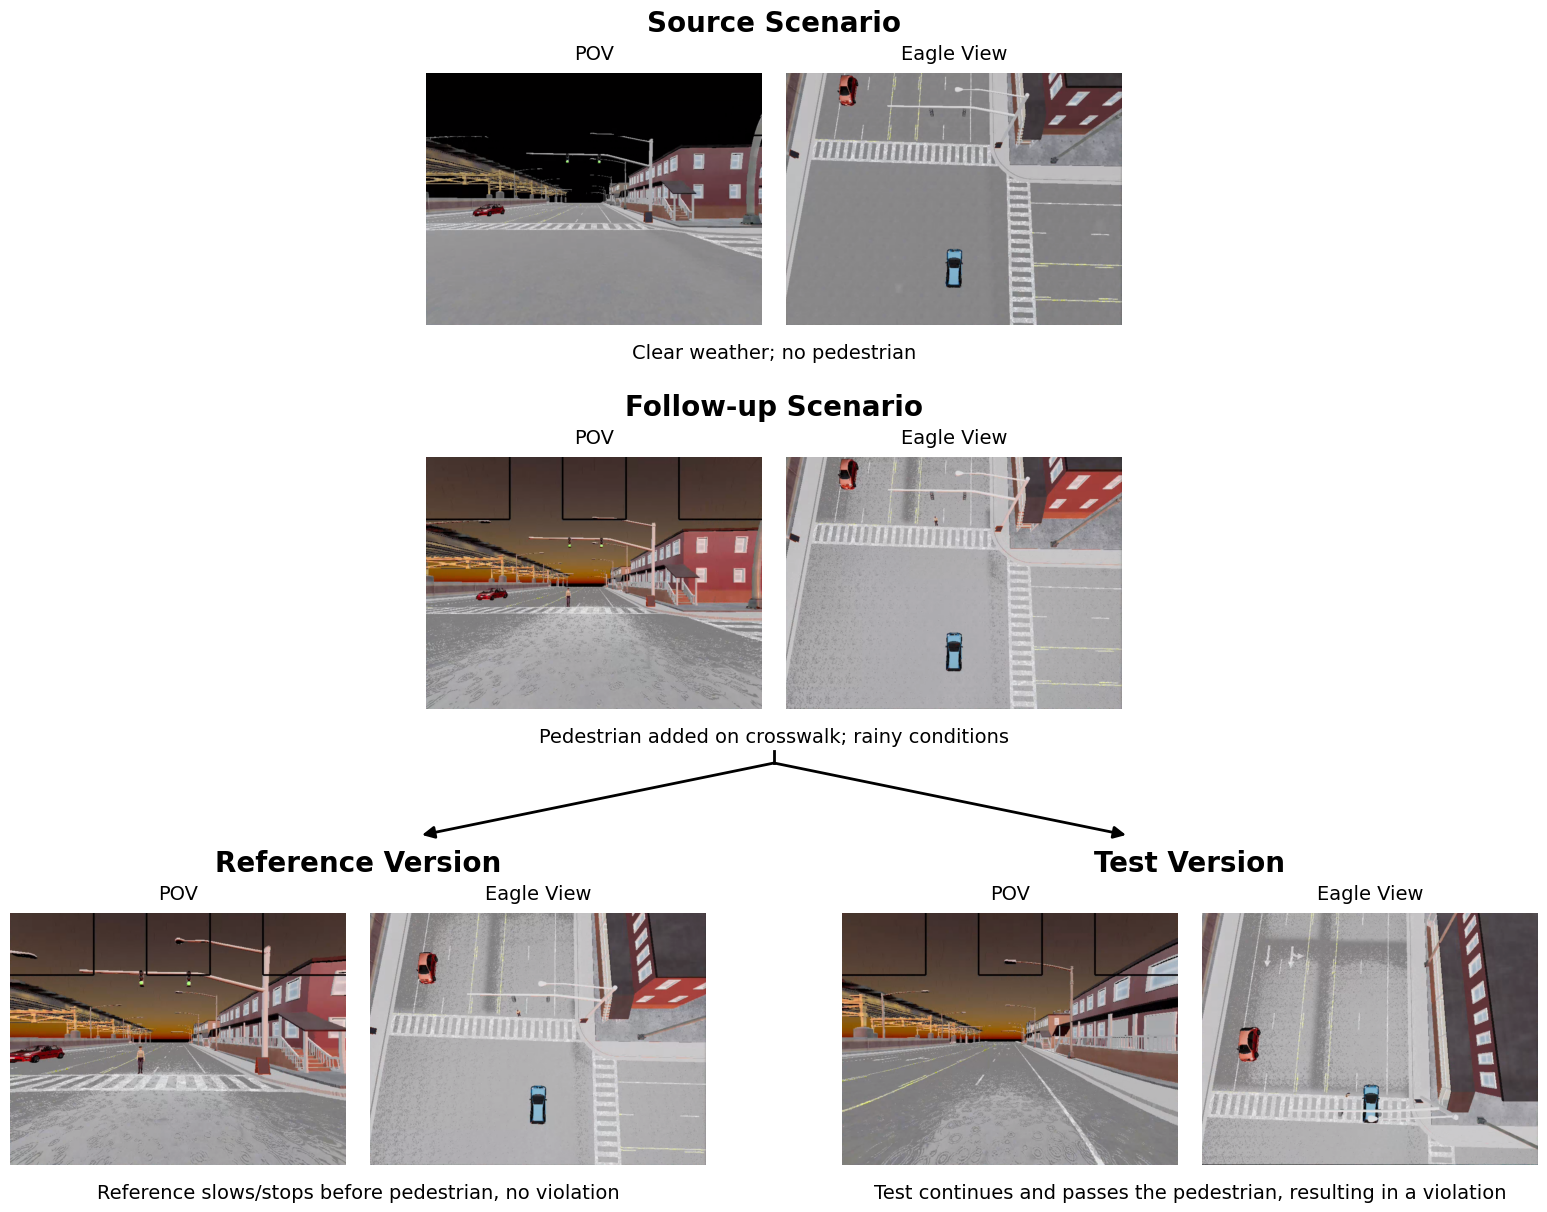

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D
from pathlib import Path

_repo_root = Path.cwd().resolve()
if not (_repo_root / "impl").exists():
    _repo_root = _repo_root.parents[1]
import importlib.util
_fe_spec = importlib.util.spec_from_file_location(
    "figure_export", _repo_root / "impl" / "ads" / "utils" / "figure_export.py")
_figure_export = importlib.util.module_from_spec(_fe_spec)
_fe_spec.loader.exec_module(_figure_export)
save_publication_figure = _figure_export.save_publication_figure

# -----------------------------
# Image paths
# -----------------------------
BASE = Path('.')
SOURCE_EAGLE = BASE / "source_eagle.png"
SOURCE_POV = BASE / "source_pov.png"
FOLLOWUP_EAGLE = BASE / "followup_eagle.png"
FOLLOWUP_POV = BASE / "followup_pov.png"
REFERENCE_EAGLE = BASE / "reference_eagle.png"
REFERENCE_POV = BASE / "reference_pov.png"
TEST_EAGLE = BASE / "test_eagle.png"
TEST_POV = BASE / "test_pov.png"

OUTPUT_PATH = BASE / "illustrative_discrepancy_branching_centered.pdf"


def load_image(path):
    """Load an image from disk."""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing image: {path}")
    return Image.open(path)


def show_image(ax, img, title=None):
    """Display an image on an axis."""
    ax.imshow(img)
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=14, pad=10, fontweight="normal")


def add_arrow(fig, start, end, color="black", lw=2.0, mutation_scale=18):
    """Draw an arrow in figure coordinates."""
    arrow = FancyArrowPatch(
        start,
        end,
        transform=fig.transFigure,
        arrowstyle="-|>",
        mutation_scale=mutation_scale,
        linewidth=lw,
        color=color,
        shrinkA=0,
        shrinkB=0,
        connectionstyle="arc3",
    )
    fig.add_artist(arrow)


def add_line(fig, start, end, color="black", lw=2.0):
    """Draw a straight line in figure coordinates."""
    line = Line2D(
        [start[0], end[0]],
        [start[1], end[1]],
        transform=fig.transFigure,
        color=color,
        linewidth=lw,
    )
    fig.add_artist(line)


def add_group_box_label(fig, x, y, text, fontsize=14):
    """Add a group label in figure coordinates."""
    fig.text(
        x,
        y,
        text,
        ha="center",
        va="center",
        fontsize=fontsize,
        fontweight="bold",
    )


def add_two_panel_group(
    fig, left, bottom, w, h, gap,
    img1, img2,
    group_title,
    desc=None,
    title_offset=0.015,
    desc_offset=0.035,
    title_fontsize=20,
    desc_fontsize=14,
):
    """Add a 2-panel group with POV and Eagle View."""

    ax1 = fig.add_axes([left, bottom, w, h])
    ax2 = fig.add_axes([left + w + gap, bottom, w, h])

    show_image(ax1, img1, "POV")
    show_image(ax2, img2, "Eagle View")

    center_x = left + w + gap / 2

    # Title above the group
    title_y = bottom + h + title_offset
    fig.text(
        center_x,
        title_y,
        group_title,
        ha="center",
        va="bottom",
        fontsize=title_fontsize,
        fontweight="bold",
    )

    # Description below the group
    if desc:
        desc_y = bottom - desc_offset
        fig.text(
            center_x,
            desc_y,
            desc,
            ha="center",
            va="top",
            fontsize=desc_fontsize,
        )

    return ax1, ax2, center_x


# Load images
source_eagle = load_image(SOURCE_EAGLE)
source_pov = load_image(SOURCE_POV)
followup_eagle = load_image(FOLLOWUP_EAGLE)
followup_pov = load_image(FOLLOWUP_POV)
reference_eagle = load_image(REFERENCE_EAGLE)
reference_pov = load_image(REFERENCE_POV)
test_eagle = load_image(TEST_EAGLE)
test_pov = load_image(TEST_POV)

# Figure
fig = plt.figure(figsize=(16, 12), facecolor="white")

# -----------------------------
# Common sizes
# -----------------------------
w = 0.21   # was 0.17 → bigger images
h = 0.22   # was 0.18
gap = 0.015  # slightly tighter spacing
group_width = 2 * w + gap

# -----------------------------
# Centered top groups
# -----------------------------
center_x = 0.5
centered_left = center_x - group_width / 2

_, _, source_center_x = add_two_panel_group(
    fig=fig,
    left=centered_left,
    bottom=0.77,
    w=w,
    h=h,
    gap=gap,
    img1=source_pov,
    img2=source_eagle,
    group_title="Source Scenario",
    desc="Clear weather; no pedestrian",
    title_offset=0.025,
    desc_offset=0.01,
)

# Follow-up (middle)
_, _, follow_center_x = add_two_panel_group(
    fig=fig,
    left=centered_left,
    bottom=0.45,
    w=w,
    h=h,
    gap=gap,
    img1=followup_pov,
    img2=followup_eagle,
    group_title="Follow-up Scenario",
    desc="Pedestrian added on crosswalk; rainy conditions",
    title_offset=0.025,
    desc_offset=0.01,   # keep description closer to images
)


# -----------------------------
# Symmetric bottom branches
# -----------------------------
branch_offset = 0.26  # slightly larger for balance with bigger images

ref_left = centered_left - branch_offset
test_left = centered_left + branch_offset

_, _, ref_center_x = add_two_panel_group(
    fig=fig,
    left=ref_left,
    bottom=0.07,
    w=w,
    h=h,
    gap=gap,
    img1=reference_pov,
    img2=reference_eagle,
    group_title="Reference Version",
    desc="Reference slows/stops before pedestrian, no violation",
    title_offset=0.025,
    desc_offset=0.01,
)

# Test
_, _, test_center_x = add_two_panel_group(
    fig=fig,
    left=test_left,
    bottom=0.07,
    w=w,
    h=h,
    gap=gap,
    img1=test_pov,
    img2=test_eagle,
    group_title="Test Version",
    desc="Test continues and passes the pedestrian, resulting in a violation",
    title_offset=0.025,
    desc_offset=0.01,
)

# -----------------------------
# Arrows / branching
# -----------------------------

split_y_top = 0.42
split_y_bottom = 0.41
add_line(fig, (follow_center_x, split_y_top), (follow_center_x, split_y_bottom))

add_arrow(fig, (follow_center_x, split_y_bottom), (ref_center_x + 0.04, 0.35))
add_arrow(fig, (follow_center_x, split_y_bottom), (test_center_x - 0.04, 0.35))

for ax in fig.axes:
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
# fig.tight_layout()
save_publication_figure(plt.gcf(), OUTPUT_PATH, bbox_inches="tight")
plt.show()